# Assignment 1: Coding/computing review

This assignment checks that your computing environment works and refreshes the Python you
will use every week. We will also attempt to apply some of the basics of ML discussed in class. It also sets up the GitHub repository you will submit all later assignments to.

We will work with the [Mauna Loa CO$_2$ record](https://gml.noaa.gov/ccgg/trends/), the longest continuous direct
measurement of atmospheric carbon dioxide anywhere in the world, running since 1958. It is
the single most recognizable dataset in climate science, and it is small enough to work with
comfortably while you are getting your tools in order.

Answer each numbered question in the empty cell below it.

```{admonition} Solution key, instructor copy
:class: danger
This is the worked solution for Assignment 1. It is kept **local only**: the
`solutions/` directory is gitignored and excluded from the book build, so it is
neither pushed to the public repository nor published to the course site.
```


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Part 1: NumPy warm-up

A quick refresher on array operations, which everything later in the course depends on.

1) Create a NumPy array of the integers 0 through 49. Reshape it into a 10 x 5 array and print its shape.

In [2]:
a = np.arange(50).reshape(10, 5)
print(a)
print("shape:", a.shape)

[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]
 [25 26 27 28 29]
 [30 31 32 33 34]
 [35 36 37 38 39]
 [40 41 42 43 44]
 [45 46 47 48 49]]
shape: (10, 5)


2) From that array, select every row where the value in the first column is greater than 20.

In [3]:
# Boolean mask on the first column, used to index rows.
rows = a[a[:, 0] > 20]
print(rows)
print("kept", len(rows), "of", len(a), "rows")

[[25 26 27 28 29]
 [30 31 32 33 34]
 [35 36 37 38 39]
 [40 41 42 43 44]
 [45 46 47 48 49]]
kept 5 of 10 rows


3) Compute the mean of each column, then the mean of each row. Explain in a sentence what the `axis` argument controls.

In [4]:
print("column means (one per column):", a.mean(axis=0))
print("row means (one per row):     ", a.mean(axis=1))

# axis names the dimension that is COLLAPSED, not the one kept. axis=0 collapses
# the rows, leaving one value per column; axis=1 collapses the columns, leaving
# one value per row.

column means (one per column): [22.5 23.5 24.5 25.5 26.5]
row means (one per row):      [ 2.  7. 12. 17. 22. 27. 32. 37. 42. 47.]


4) Create an array of 100 evenly spaced values between 0 and $4\pi$, compute its sine, and report how many values are positive.

In [5]:
x = np.linspace(0, 4 * np.pi, 100)
s = np.sin(x)
print("positive values:", (s > 0).sum(), "of", s.size)

positive values: 49 of 100


## Part 2: Load the Mauna Loa CO$_2$ record

The data comes directly from NOAA's Global Monitoring Laboratory. The file has about 40
lines of header comments before the data begins, which `comment="#"` skips.

In [6]:
url = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv"
co2 = pd.read_csv(url, comment="#")
co2 = co2.rename(columns={"decimal date": "decimal_date"})

# Build a proper datetime column (measurements are monthly means, dated mid-month).
co2["date"] = pd.to_datetime(dict(year=co2["year"], month=co2["month"], day=15))

# NOAA codes missing monthly means as -99.99.
co2 = co2[co2["average"] > 0].reset_index(drop=True)

co2.head()

,year,month,decimal_date,average,deseasonalized,ndays,sdev,unc,date
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99,1958-03-15
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99,1958-04-15
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99,1958-05-15
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99,1958-06-15
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99,1958-07-15


5) How many monthly observations are in the record, and what date range does it cover?

In [7]:
print("observations:", len(co2))
print("from", co2["date"].min().date(), "to", co2["date"].max().date())

observations: 821
from 1958-03-15 to 2026-07-15


6) Use `.describe()` on the `average` column. What were the lowest and highest monthly mean CO$_2$ concentrations recorded?

In [8]:
print(co2["average"].describe())
lo, hi = co2["average"].idxmin(), co2["average"].idxmax()
print("\nlowest :", co2.loc[lo, "average"], "ppm in", co2.loc[lo, "date"].date())
print("highest:", co2.loc[hi, "average"], "ppm in", co2.loc[hi, "date"].date())

count    821.000000
mean     361.279805
std       33.396504
min      312.420000
25%      331.280000
50%      356.340000
75%      387.630000
max      432.340000
Name: average, dtype: float64

lowest : 312.42 ppm in 1958-10-15
highest: 432.34 ppm in 2026-05-15


7) Check for missing values in each column. Which columns have them, and why might that be? (Look at the NOAA header comments if you are unsure what `sdev` and `unc` mean.)

In [9]:
print(co2.isna().sum())

# Nothing is NaN -- but that does not mean nothing is missing. NOAA codes absent
# values with negative sentinels, which pandas reads as ordinary numbers:
print("\nsentinel-coded missing values:")
print("  ndays == -1 :", (co2["ndays"] == -1).sum())
print("  sdev  < 0   :", (co2["sdev"] < 0).sum())
print("  unc   < 0   :", (co2["unc"] < 0).sum())
print("\nlast year with a sentinel:", int(co2.loc[co2["ndays"] == -1, "year"].max()))

# sdev is the standard deviation of the daily means within the month and unc the
# uncertainty of the monthly mean; both need daily values to compute. Before 1974
# the record comes from a different measurement programme that did not archive
# daily counts, so ndays/sdev/unc are unavailable and carry -1 / -9.99 / -0.99.
# This is why you check the header rather than trusting .isna().

year              0
month             0
decimal_date      0
average           0
deseasonalized    0
ndays             0
sdev              0
unc               0
date              0
dtype: int64

sentinel-coded missing values:
  ndays == -1 : 195
  sdev  < 0   : 196
  unc   < 0   : 194

last year with a sentinel: 1975


## Part 3: Plotting

Every figure you produce in this course needs axis labels and units. Get in the habit now.

8) Plot the monthly mean CO$_2$ concentration against date. Label both axes, include units, and give the figure a title.

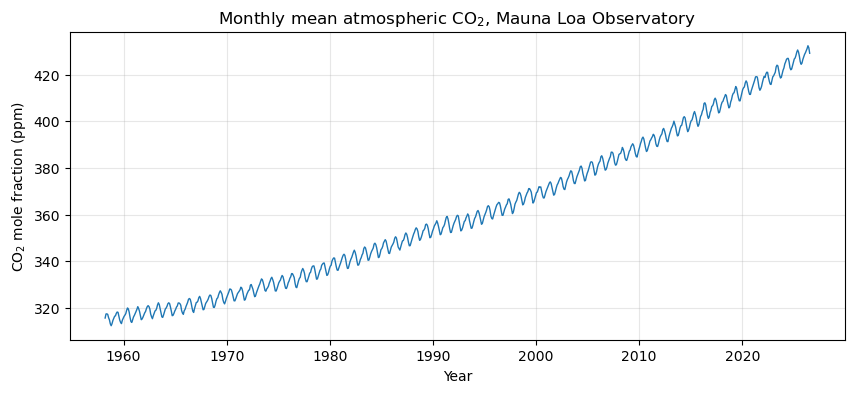

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(co2["date"], co2["average"], lw=1)
ax.set_xlabel("Year")
ax.set_ylabel("CO$_2$ mole fraction (ppm)")
ax.set_title("Monthly mean atmospheric CO$_2$, Mauna Loa Observatory")
ax.grid(alpha=0.3)
plt.show()

9) On the same axes, plot both the `average` and `deseasonalized` series. Add a legend. What does the deseasonalized series remove?

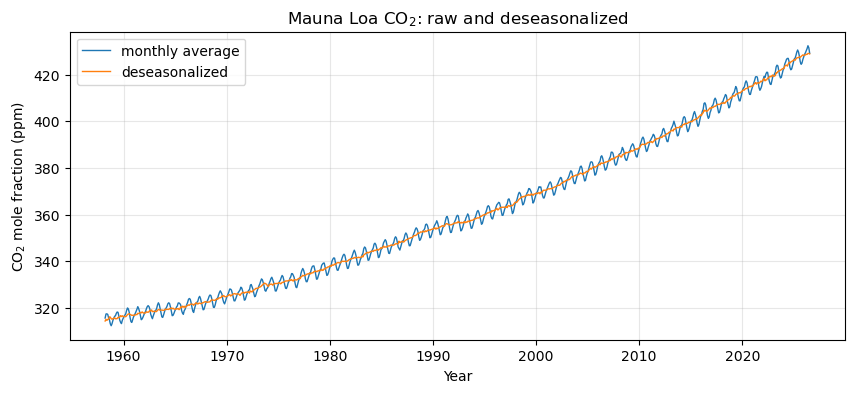

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(co2["date"], co2["average"], lw=1, label="monthly average")
ax.plot(co2["date"], co2["deseasonalized"], lw=1, label="deseasonalized")
ax.set_xlabel("Year")
ax.set_ylabel("CO$_2$ mole fraction (ppm)")
ax.set_title("Mauna Loa CO$_2$: raw and deseasonalized")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

# The deseasonalized series removes the repeating within-year oscillation driven
# by Northern Hemisphere vegetation, leaving the long-term trend. The two curves
# sit on top of each other at this scale precisely because the seasonal swing
# (~6 ppm) is small next to the ~110 ppm rise since 1958.

10) Zoom in on a five-year window of your choice and plot the `average` series alone. Describe the shape you see within each year.

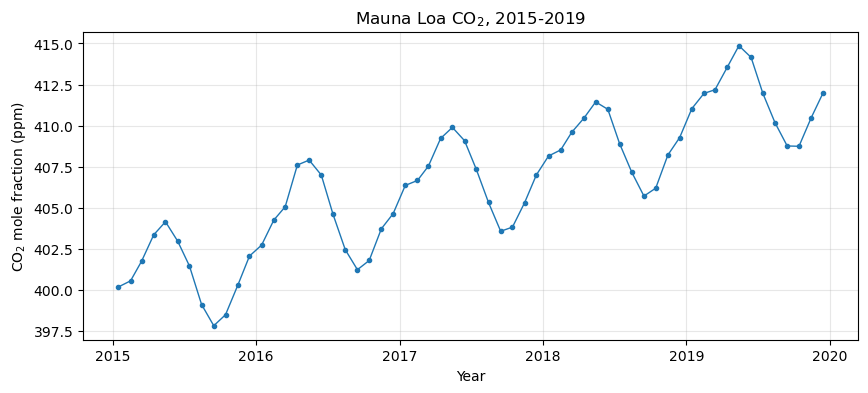

In [12]:
window = co2[(co2["year"] >= 2015) & (co2["year"] <= 2019)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(window["date"], window["average"], marker="o", ms=3, lw=1)
ax.set_xlabel("Year")
ax.set_ylabel("CO$_2$ mole fraction (ppm)")
ax.set_title("Mauna Loa CO$_2$, 2015-2019")
ax.grid(alpha=0.3)
plt.show()

# Within each year the curve climbs through the winter to a May maximum, drops
# sharply through the summer to a September/October minimum, then climbs again --
# a sawtooth riding on a steady upward trend. Each year's minimum is higher than
# the previous year's minimum.

## Part 4: The seasonal cycle and the trend

The Mauna Loa record has two clear signals: a long-term rise, and an annual oscillation
driven by Northern Hemisphere vegetation taking up carbon in spring and summer and releasing
it in autumn and winter.

11) Compute the seasonal cycle: group by calendar month and take the mean of `average - deseasonalized`. Plot it against month number.

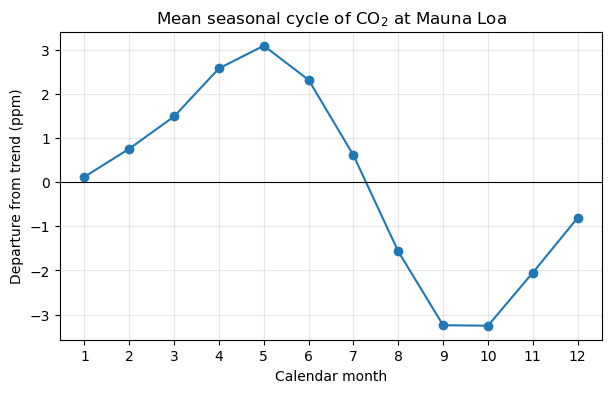

month
1     0.12
2     0.76
3     1.49
4     2.57
5     3.09
6     2.31
7     0.61
8    -1.57
9    -3.24
10   -3.25
11   -2.05
12   -0.81
Name: seasonal, dtype: float64


In [13]:
co2["seasonal"] = co2["average"] - co2["deseasonalized"]
cycle = co2.groupby("month")["seasonal"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(cycle.index, cycle.values, marker="o")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(range(1, 13))
ax.set_xlabel("Calendar month")
ax.set_ylabel("Departure from trend (ppm)")
ax.set_title("Mean seasonal cycle of CO$_2$ at Mauna Loa")
ax.grid(alpha=0.3)
plt.show()

print(cycle.round(2))

12) In which month does CO$_2$ peak, and in which does it bottom out? Explain the timing in terms of the Northern Hemisphere growing season.

In [14]:
print("peak month:  ", cycle.idxmax(), f"({cycle.max():+.2f} ppm)")
print("trough month:", cycle.idxmin(), f"({cycle.min():+.2f} ppm)")
print("peak-to-trough amplitude:", round(cycle.max() - cycle.min(), 2), "ppm")

# CO2 peaks in May and bottoms out in September/October. Most of the world's land
# vegetation is in the Northern Hemisphere, so the global signal follows the NH
# growing season. Through winter, respiration and decay release carbon while
# little photosynthesis offsets it, so CO2 accumulates to a May maximum -- just
# before leaf-out gets going. Through the summer, photosynthesis draws CO2 down
# faster than respiration returns it, reaching a minimum at the end of the
# growing season. The cycle is the biosphere breathing once a year.

peak month:   5 (+3.09 ppm)
trough month: 10 (-3.25 ppm)
peak-to-trough amplitude: 6.34 ppm


13) Compute the annual mean CO$_2$ for each complete year, then the year-over-year increase. Plot that growth rate against year.

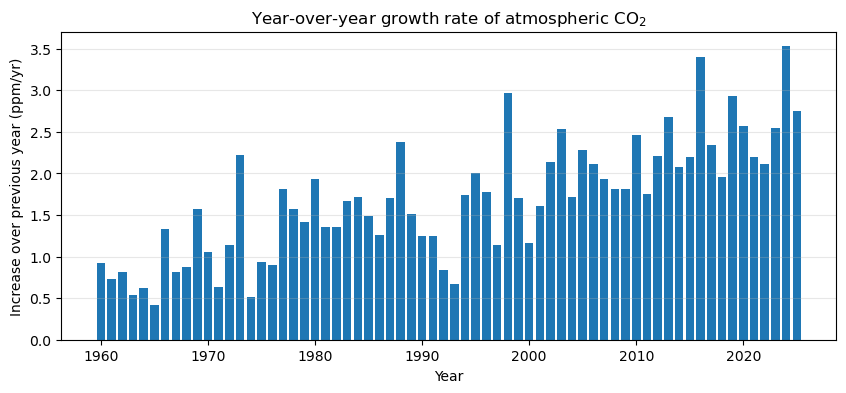

mean growth rate, first decade: 0.86 ppm/yr
mean growth rate, last decade:  2.63 ppm/yr


In [15]:
counts = co2.groupby("year")["average"].count()
complete = counts[counts == 12].index          # only full years
annual = co2[co2["year"].isin(complete)].groupby("year")["average"].mean()
growth = annual.diff().dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(growth.index, growth.values)
ax.set_xlabel("Year")
ax.set_ylabel("Increase over previous year (ppm/yr)")
ax.set_title("Year-over-year growth rate of atmospheric CO$_2$")
ax.grid(alpha=0.3, axis="y")
plt.show()

print("mean growth rate, first decade:", round(growth.iloc[:10].mean(), 2), "ppm/yr")
print("mean growth rate, last decade: ", round(growth.iloc[-10:].mean(), 2), "ppm/yr")

14) Fit a straight line to the full record using `numpy.polyfit` on `decimal_date` against `average`. What average annual increase does the slope imply?

slope     = 1.669 ppm per year
intercept = -2963.8 ppm


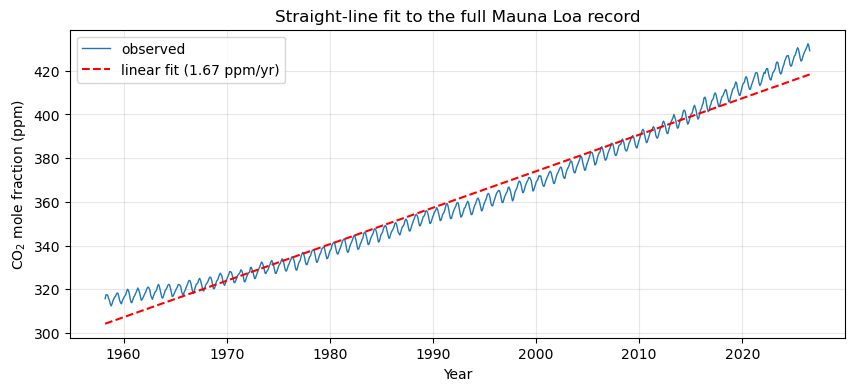

In [16]:
slope, intercept = np.polyfit(co2["decimal_date"], co2["average"], 1)
print(f"slope     = {slope:.3f} ppm per year")
print(f"intercept = {intercept:.1f} ppm")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(co2["date"], co2["average"], lw=1, label="observed")
ax.plot(co2["date"], slope * co2["decimal_date"] + intercept, "r--",
        label=f"linear fit ({slope:.2f} ppm/yr)")
ax.set_xlabel("Year")
ax.set_ylabel("CO$_2$ mole fraction (ppm)")
ax.set_title("Straight-line fit to the full Mauna Loa record")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

15) Looking at your growth rate plot from question 13, is a straight line a good description of this record? Answer in two or three sentences, referring to what you see.

**No: a straight line is a poor description of this record, and the growth-rate
plot from question 13 is what shows it.**

A straight line asserts one constant rate of increase for the whole record. But
the year-over-year growth rate is not constant: it averages roughly 0.9 ppm/yr
over the first decade of the record and roughly 2.6 ppm/yr over the most recent
decade. The rate has itself roughly tripled, so the underlying curve is convex,
not linear.

You can see the consequence directly in the fitted line from question 14: it sits
*above* the observations in the middle of the record and *below* them at both
ends. That systematic pattern in the residuals (rather than scatter with no structure) is the signature of fitting a straight line to something curved. The
single slope of about 1.7 ppm/yr is a average over the record; it overstates the
1960s and understates the present, and it describes no actual decade well.

(The growth-rate plot is also noisy from year to year, with spikes in strong El
Niño years such as 1998 and 2016, when drought and fire reduce the land carbon
sink. That interannual variability rides on top of the acceleration.)

## Part 5: Intro to ML

The lecture notes for this week lay out the vocabulary: the three learning paradigms, the eight-step workflow, and the
strengths and weaknesses of data-driven methods.

Each question below asks you to apply these principles to the Mauna Loa record from this assignment.

16) Before answering anything conceptual, run one experiment.

Refit your straight line using **only the data up to the end of 1999**, then use it to
predict CO$_2$ for 2000 onwards. Plot the observations for the whole record together with
the extrapolated line, and report the prediction error in ppm for the most recent year in
the dataset.

fitted on 1958-1999 (502 months)
  slope = 1.323 ppm/yr   (full-record slope was 1.669)


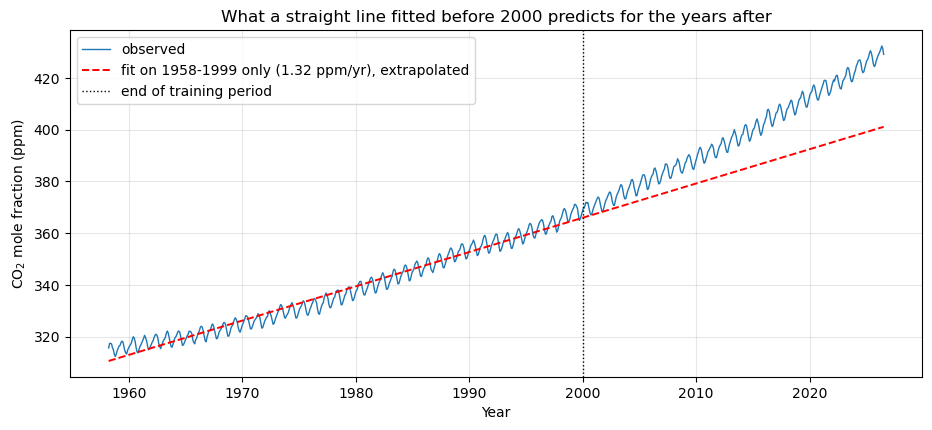


2026: observed mean 430.3 ppm, predicted 400.8 ppm
  error = +29.5 ppm  (positive means the model UNDER-predicts)

mean error over 2000-2026: +13.9 ppm


In [17]:
# Fit using only the record through the end of 1999.
early = co2[co2["year"] <= 1999]
slope_e, intercept_e = np.polyfit(early["decimal_date"], early["average"], 1)
print(f"fitted on {early['year'].min()}-{early['year'].max()} "
      f"({len(early)} months)")
print(f"  slope = {slope_e:.3f} ppm/yr   (full-record slope was {slope:.3f})")

co2["extrapolated"] = slope_e * co2["decimal_date"] + intercept_e

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(co2["date"], co2["average"], lw=1, label="observed")
ax.plot(co2["date"], co2["extrapolated"], "r--", lw=1.4,
        label=f"fit on 1958-1999 only ({slope_e:.2f} ppm/yr), extrapolated")
ax.axvline(pd.Timestamp("2000-01-01"), color="k", ls=":", lw=1,
           label="end of training period")
ax.set_xlabel("Year")
ax.set_ylabel("CO$_2$ mole fraction (ppm)")
ax.set_title("What a straight line fitted before 2000 predicts for the years after")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

last_year = int(co2["year"].max())
recent = co2[co2["year"] == last_year]
err = (recent["average"] - recent["extrapolated"]).mean()
print()
print(f"{last_year}: observed mean {recent['average'].mean():.1f} ppm, "
      f"predicted {recent['extrapolated'].mean():.1f} ppm")
print(f"  error = {err:+.1f} ppm  (positive means the model UNDER-predicts)")
print()
post = co2[co2["year"] >= 2000]
print(f"mean error over 2000-{last_year}: "
      f"{(post['average'] - post['extrapolated']).mean():+.1f} ppm")

# The extrapolation drifts steadily below the observations, and the gap widens every year.
# The straight line was not a bad fit to 1958-1999 -- it was a bad MODEL, because the record
# is curved and a line cannot bend. Fitting a curved process with a straight line is
# survivable while you stay inside the fitted range and becomes progressively worse the
# further outside it you go.

17) You have now fit a model that learned two parameters from data (slope and intercept) and made predictions
without anyone programming the relationship explicitly. By the definition given in the
lecture notes, **is `numpy.polyfit` a machine learning algorithm?**. Justify your answer.

**The case *for* calling it machine learning.**

It satisfies the notes' own definition almost word for word. The notes say machine learning
methods "automatically learn from data" and "predict without being explicitly programmed to
perform a specific task". Nobody told `polyfit` that CO$_2$ rises by 1.67 ppm each year; it
determined that from the data by minimizing a loss function (squared error) and it then
produced predictions for inputs it had never seen. It has training data, learned parameters,
a loss, and an inference step. Four of the eight workflow stages in the notes map onto it
directly.

The strongest form of this argument is that **linear regression is uncontroversially a
machine learning algorithm** in every other context. It is in `scikit-learn`, it is the
first model in most ML textbooks, and it is exactly what Assignment 3 will use for a
regression task. `numpy.polyfit` and `sklearn.linear_model.LinearRegression` solve the same
optimization problem; the second is called machine learning because of the library it lives
in, which is not a property of the algorithm.

**The case *against*.**

The functional form was chosen entirely by me. The model could never have discovered that
the relationship is curved, or seasonal, or anything other than a line, I specified the
degree, and the only thing "learned" was two coefficients within a structure I imposed. On
this view machine learning is characterized by the model discovering *structure*, not just
constants, and polyfit discovers no structure at all.

There is also no generalization machinery: no held-out validation, no hyperparameters, no
guard against overfitting, and a closed-form solution rather than iterative optimization.
Nothing about it improves "with new observations" in the sense the notes describe. And
historically, least squares dates to Legendre and Gauss around 1805, calling it machine
learning makes the term cover essentially all of statistics and stop distinguishing
anything.

**Which is more convincing, and what would settle it.**

I find the case *for* more convincing, but with the concession that the question is not
really a technical one. There is no property of `polyfit` that a defender of "this is ML"
must deny; the disagreement is about where to draw a boundary on a continuum, and that
boundary is drawn by convention and by academic culture rather than by mathematics. Least
squares, ridge regression, a shallow neural network and a transformer differ in capacity and
in how they are fitted, not in kind: all minimize a loss over parameters. The honest answer
is that the notes' definition is broad enough to include polyfit, and that this is a feature
of the definition rather than a mistake in it.

The additional criterion I would propose is **whether the model's capacity is itself chosen
by confronting held-out data**. Under that criterion, `polyfit` with a degree I picked is
statistics; `polyfit` where I selected the degree by cross-validation is machine learning,
because a decision that would otherwise be mine has been delegated to the data. This is a
sharper line than "learns from data", it explains why validation is treated as central to
the discipline, and it is the reason Assignment 5 is devoted to it. It also has the honest
consequence that the same algorithm can fall on either side depending on how it was used,
which I think is correct, because the difference really is in the methodology, not the
equation.

18) The notes divide machine learning into supervised, unsupervised, and reinforcement
learning. Consider two things you did earlier in this assignment:

- **(a)** the straight-line fit of concentration against date (question 14)
- **(b)** the seasonal cycle you extracted by grouping on calendar month (question 11)

Which paradigm, if any, does each belong to? 

**(a) The straight-line fit is supervised learning.** Each training example is a pair (a `decimal_date` as the input feature and an `average` concentration as the label) and the
model is fitted by comparing its output against those known labels. It is a regression
problem, since the label is continuous. This is a clean fit to the definition.

Though it is worth noticing something slightly uncomfortable even here: the "label" is not an
independent annotation of the kind the notes have in mind when they describe labelling
images as cats or dogs. Nobody had to decide what the answer was; both numbers came off the
same instrument. What makes it supervised is the *structure of the task* (one variable designated as the thing to predict) not the existence of a labelling effort.

**(b) The seasonal cycle does not fit any of the three, and that is the interesting part.**

It is not supervised: there is no label being predicted and no notion of error against a
ground truth. It is not reinforcement learning: there is no agent, no action, no reward. The
tempting answer is unsupervised, since the notes describe that paradigm as identifying
"underlying patterns and correlations inherent to the data itself", and a seasonal cycle is
certainly a pattern inherent to the data.

But nothing was *learned*. `groupby("month").mean()` is an average. It has no parameters
fitted by optimization, no loss function, no capacity to be overfitted, and no ability to
generalize to anything; it simply summarizes the data it was given, and it would return the
same twelve numbers whether or not one believed there was a seasonal cycle at all. Calling
it unsupervised learning would equally make the median, the standard deviation, and drawing
a histogram into machine learning.

**What this reveals about the three-way division.** It classifies *supervision signals*, not
data analysis. The question it answers is "what kind of feedback does the algorithm get
during training?": labels, none, or a reward. That is a genuinely useful axis for
algorithms that train. It says nothing about methods that do not train, and descriptive
statistics is most of what climate science actually does. Computing a climatology, taking an
anomaly, plotting a trend, calculating an index, none of these belong in the taxonomy, and
none of them are worse for it.

So the taxonomy is a map of one region rather than a map of the whole territory, and the
practical lesson is to be suspicious of the reflex to file every analysis into one of three
boxes. The prior question is whether a model is being fitted at all. In this assignment, one
of the two analyses fitted a model and one summarized data, and the more useful distinction
between them is exactly that one.

19) Frame a genuine **supervised learning** problem using this dataset. You are not being asked to implement it. Your answer must
specify, concretely:

- the input features and the label, and be careful, because a naive choice here makes the
  problem either trivial or impossible
- how you would split the data into training and test sets, and why the obvious split is a
  bad idea for a record like this one
- what loss function you would minimize
- what result would make you conclude the model had learned something real, as opposed to
  something you already knew



**The problem: predict next month's CO$_2$ concentration from the recent past.**

**Features and label.** The label is the concentration in month $t$. The features are the
twelve preceding monthly values, $t-1$ through $t-12$, plus the calendar month encoded as a
pair of sinusoids, $\sin(2\pi m/12)$ and $\cos(2\pi m/12)$.

The naive choice the question warns about is using **date as the only feature**. That is
what question 14 did, and it makes the problem degenerate: with one monotonically increasing
input there is nothing to learn beyond a trend line, and every prediction outside the
training period is pure extrapolation. The opposite failure is including a feature already
containing the answer: the `deseasonalized` column, for instance, is a smoothed version of
`average` computed by NOAA from the very value being predicted, so a model given it would
score almost perfectly and have learned nothing. Both are ways of making the task either
trivial or impossible, and the useful framing sits between them: give the model the recent
history and require it to project one step forward.

**The split, and why the obvious one is wrong.** The obvious split is random, shuffle the
months, hold out 20%. It is badly wrong here for two compounding reasons. First, consecutive
months are nearly identical, so a random split leaves the model with the months either side
of almost every test month and reduces the task to interpolation. Second, and more seriously,
this feature set makes the target of one row an explicit *feature* of the neighbouring rows:
month $t$ appears as a lagged feature for months $t+1$ through $t+12$. Under a random split
the answer is sitting in the training set, not merely approximated by it.

The correct split is **chronological**: train on 1958 through roughly 2010, validate on the
next several years, test on the most recent block. That is also the only split matching how
such a model would be used, fitted on the record so far and run forward.

**Loss.** Mean squared error on the concentration. Squared error is the right default for a
continuous target with roughly symmetric, well-behaved errors, and this series has no heavy
tail to worry about. I would report **RMSE in ppm** rather than the raw loss, because ppm is
interpretable and can be compared against the roughly 0.1–0.3 ppm measurement uncertainty of
the instrument itself.

**What would count as having learned something real.** Not beating the mean; that bar is
meaninglessly low for a series with a strong trend. The model must beat two much harder
baselines:

1. **Persistence**: next month equals this month. On a smooth series this is already good.
2. **Seasonal-naive plus trend**: this month last year, plus the average annual increase.
   This encodes everything already known about the record (that it rises steadily and repeats annually) and is genuinely hard to beat.

Beating persistence alone would show only that the model noticed the seasonal cycle. Beating
the second baseline would mean it had extracted something beyond "steady rise plus repeating
annual wiggle", most plausibly interannual variability such as the enhanced growth rate
during strong El Niño years. That would be a real, if modest, finding. If the model matched
but did not beat that baseline, the honest report is that the record contains little
predictable structure beyond trend and season, which is itself a useful scientific
statement, and a more likely outcome than beating it.

**A limitation worth stating up front.** Any model trained on this dataset learns the
behaviour of one station on a Pacific volcano. Mauna Loa was sited precisely because it
samples well-mixed background air, so it is unrepresentative of continental sites with local
sources by design. A model fitted here would not transfer to an urban monitoring station,
and its apparent skill would say nothing about performance there.

20) The notes state that machine learning models "typically do a poor job of extrapolating
to unseen data regimes." Your experiment in question 16 is a small demonstration of exactly
that.

Suppose you needed a projection of atmospheric CO$_2$ for the year 2100. Would a flexible
machine learning model (a neural network, say) trained on this same record do **better or
worse** than your straight line? Explain your reasoning, and then explain what a
physics-based carbon cycle model has access to that neither of them does.

**Worse (probably much worse) and the reason a neural network fails here is the same
reason it succeeds elsewhere.**

A neural network's advantage is flexibility: it can represent essentially any shape without
being told the functional form. Inside the range of the training data that is exactly what
you want. Outside it, it becomes the liability, because flexibility means the model has no
commitment to any particular behaviour once it leaves the region where data constrained it.
A network fitted to 1958–2026 would reproduce that period beautifully (trend, seasonal cycle, the interannual wiggles) and its output for 2100 would be governed by whatever its
activation functions happen to do far from any training point. With ReLU units that is a
linear ramp whose slope is an artefact of the final layer's weights; with saturating units it
flattens to a constant. Neither is a statement about carbon. Worse, the model's flexibility
means small changes in fitting (a different random seed, a few more epochs) would give
noticeably different 2100 values, while all fitting the historical record equally well. A
projection that depends on the random seed is not a projection.

The straight line does better only in the weak sense that it fails predictably. It encodes
one global assumption (a constant rate of increase) which is at least a claim about the
world that can be checked and rejected. Question 16 rejects it: fitted before 2000 it
under-predicts thereafter, because the true growth rate has roughly tripled over the record.
So the line is *also* wrong for 2100, and wrong in a known direction. Being wrong
transparently is a genuine advantage over being wrong arbitrarily, but it is not skill.

**What a physics-based carbon cycle model has that neither has.**

The decisive difference is not sophistication, it is **what the models take as input**.
Atmospheric CO$_2$ in 2100 is not a function of atmospheric CO$_2$ in the past. It is
mostly a function of **how much carbon humans emit between now and then**, and that quantity
appears nowhere in this dataset. It depends on energy policy, technology and economics,
things no amount of curve-fitting on the historical record can anticipate. This is why
climate projections are always reported *per emissions scenario*: the scenario is an input,
not a prediction. A statistical model extrapolating the Mauna Loa curve is implicitly
assuming the last seventy years of emissions growth continues unchanged, and it cannot
represent any alternative because it has no place to put one.

Beyond that, a carbon cycle model carries structure that constrains it where data does not:

- **Mass conservation.** Carbon is tracked between atmosphere, ocean and land. The model
  cannot produce atmospheric growth that fails to balance, whereas a fitted curve is under
  no such obligation.
- **Process representation of the sinks.** Roughly half of emitted CO$_2$ is currently
  absorbed by ocean and land. That fraction is not constant: ocean uptake slows as surface
  water acidifies and warms, and the land sink responds to CO$_2$ fertilization, temperature
  and drought. These are *feedbacks*, and they may weaken this century. A model without them
  cannot represent the most important nonlinearity in the problem.
- **The ability to be wrong in a diagnosable way.** When a physics model errs you can ask
  which process is misrepresented. When an extrapolated fit errs there is nothing to
  interrogate.

The general lesson, and the one the notes are pointing at: machine learning interpolates
within the regime it has seen. Climate projection is an extrapolation problem *by
definition*: the whole question is about a state of the system that has not occurred yet.
That is why ML has been transformative for weather prediction and emulation, which operate
inside the observed regime, while long-range projection remains the domain of process-based
models. The productive uses of ML in this space are hybrid: emulating an expensive physics
model to explore scenarios quickly, or replacing an individual parameterization inside one,
where the physics supplies the constraints and the ML supplies the speed.

## Part 6: Create your assignments repository

You will submit every assignment in this course by pushing to a private GitHub repository.
Set it up now.

1. Create a directory called `ml4climate2026` on your machine.
2. Add a `README.md` containing your name.
3. Initialize a git repository, and make your first commit.
4. Create a **private** repository on GitHub called `ml4climate2026`. Use exactly that name.
   Do not vary the spelling, capitalization, or punctuation.
5. Push your local repository to GitHub.
6. On GitHub, go to **Settings -> Collaborators** and add `dmw2166`.
7. Add this completed notebook to the repository, commit, and push.

Push new commits to this repository whenever you are ready to hand in an assignment.

21) Paste the output of `git log --oneline` below, showing your commit history.

In [18]:
# Run this in your ml4climate2026 repository, then paste the output here.
# Your history will differ; this is the shape it should take.
#
# $ git log --oneline
# 8f3c1a2 Add completed Assignment 1 notebook
# 1d9e4b7 Initial commit: README with my name